# Notebook 03 — Aprendizaje No Supervisado
**PCA + K-Means · NHANES 2013-2014 con Data Augmentation · Autor: Nicholas**

**Objetivo:** Descubrir fenotipos o perfiles metabólicos ocultos en la población
adulta de NHANES 2013-2014 usando técnicas de aprendizaje no supervisado.

**¿Por qué No Supervisado?**
A diferencia de la clasificación supervisada (Notebook 04), aquí **no usamos la
etiqueta `IS_LONGEVO`**. El algoritmo encuentra agrupaciones naturales basándose
exclusivamente en los biomarcadores de salud, lo que permite:
- Identificar perfiles de riesgo que el negocio no había definido a priori.
- Validar si los clusters descubiertos coinciden con la longevidad real.
- Generar segmentos de pacientes útiles para la app de Edad Biológica.

**Pipeline:**
1. PCA — Análisis de Componentes Principales (reducción de dimensionalidad)
2. K-Means — Agrupamiento en K clusters
3. Validación — Método del Codo + Silhouette Score
4. Interpretación de centroides — perfiles de salud

---

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, warnings

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams.update({'figure.figsize': (14, 6),
                     'axes.titleweight': 'bold', 'axes.titlesize': 14})

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga de datos preprocesados

Usamos el dataset generado en el Notebook 02, que ya está:
- Libre de nulos (imputado con KNNImputer + SimpleImputer)
- Con variables categóricas codificadas (One-Hot Encoding)
- Con variables numéricas escaladas (StandardScaler)

> **Importante:** PCA y K-Means son sensibles a la escala.
> Se eliminan `IS_LONGEVO` y `CICLO_ORIGEN` de las features para que K-Means
> no tenga acceso a información que queremos descubrir.

In [2]:
DATA_PATH = '../data/02_intermediate/nhanes_2013_procesado.parquet'
META_PATH = '../data/02_intermediate/metadata_preprocesamiento_2013.json'

df = pd.read_parquet(DATA_PATH)

try:
    with open(META_PATH, 'r') as f:
        meta = json.load(f)
    print("Metadatos cargados desde JSON.")
except (FileNotFoundError, json.JSONDecodeError):
    print("JSON de metadatos no disponible. Derivando info del CSV...")
    cols_excluir = ['SEQN', 'RIDAGEYR', 'IS_LONGEVO', 'CICLO_ORIGEN']
    meta = {'todas_las_features': [c for c in df.columns if c not in cols_excluir]}

if 'CICLO_ORIGEN' in df.columns:
    print(f"Eliminando CICLO_ORIGEN (solo trazabilidad, no biomarcador).")
    df = df.drop(columns=['CICLO_ORIGEN'])

print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Nulos: {df.isnull().sum().sum()}")
df.head(3)

Metadatos cargados desde JSON.
Eliminando CICLO_ORIGEN (solo trazabilidad, no biomarcador).
Dataset cargado: 10,214 filas × 41 columnas
Nulos: 0


,SEQN,RIDAGEYR,DMDHHSIZ,DMDFMSIZ,INDFMPIR,BMXWT,BMXHT,BMXBMI,BMXWAIST,BMXLEG,...,DMDEDUC2_5,DMDEDUC2_7,DMDEDUC2_9,DMDMARTL_2,DMDMARTL_3,DMDMARTL_4,DMDMARTL_5,DMDMARTL_6,DMDMARTL_77,DMDMARTL_99
0,73557.0,69.0,0.095499,0.173546,-1.039895,-0.032480,0.548759,-0.296851,0.033043,0.302509,...,0,0,0,0,0,1,0,0,0,0
1,73558.0,54.0,0.699478,0.778943,-0.422015,0.523043,1.097365,-0.003424,0.524268,0.509954,...,0,0,0,0,0,0,0,0,0,0
2,73559.0,72.0,-0.508480,-0.431850,1.372469,0.493283,0.947745,0.042907,0.627684,0.509954,...,0,0,0,0,0,0,0,0,0,0


## 3. Preparación de la matriz de features X

In [3]:
cols_excluir = ['SEQN', 'RIDAGEYR', 'IS_LONGEVO']
feature_cols = [c for c in df.columns if c not in cols_excluir]

X = df[feature_cols].values

print(f"Matriz de features X: {X.shape}")
print(f"Columnas ({len(feature_cols)}): {feature_cols[:10]} ...")

Matriz de features X: (10214, 38)
Columnas (38): ['DMDHHSIZ', 'DMDFMSIZ', 'INDFMPIR', 'BMXWT', 'BMXHT', 'BMXBMI', 'BMXWAIST', 'BMXLEG', 'BMXARML', 'BMXARMC'] ...


## 4. PCA — Análisis de Componentes Principales

**¿Por qué PCA?**
- Con ~38 features la visualización directa es imposible.
- PCA proyecta en 2-3 dimensiones conservando la mayor varianza posible.
- Elimina ruido (los componentes menores capturan ruido, no señal real).
- Mejora K-Means: en alta dimensionalidad las distancias euclidianas pierden
  significado ("maldición de la dimensionalidad").

Primero aplicamos PCA completo para ver cuánta varianza explica cada componente.

In [4]:
# PCA completo
pca_full = PCA(random_state=42)
pca_full.fit(X)

varianza_exp = pca_full.explained_variance_ratio_
varianza_acum = np.cumsum(varianza_exp)

df_varianza = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(varianza_exp))],
    'Varianza Explicada %': (varianza_exp * 100).round(2),
    'Varianza Acumulada %': (varianza_acum * 100).round(2),
})

print("Varianza explicada por componente (primeros 10):")
print(df_varianza.head(10).to_string(index=False))

Varianza explicada por componente (primeros 10):
Componente  Varianza Explicada %  Varianza Acumulada %
       PC1                 20.75                 20.75
       PC2                 16.58                 37.33
       PC3                 12.36                 49.69
       PC4                 10.64                 60.33
       PC5                  7.41                 67.73
       PC6                  5.01                 72.75
       PC7                  4.59                 77.34
       PC8                  4.44                 81.78
       PC9                  3.85                 85.63
      PC10                  1.75                 87.38


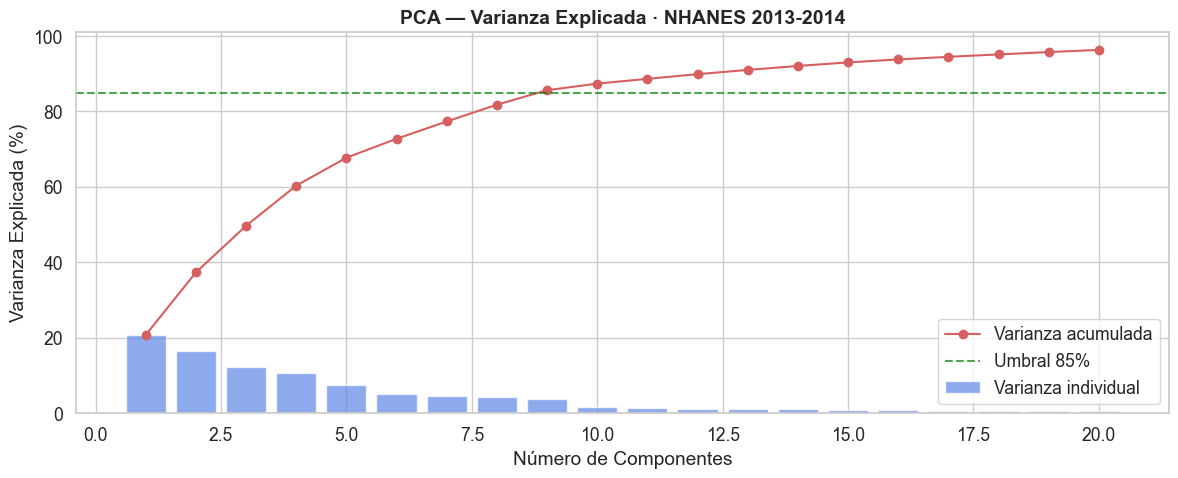

Componentes necesarios para ≥85% de varianza: 9


In [5]:
# Gráfico de varianza acumulada
fig, ax = plt.subplots(figsize=(12, 5))
n_comp = min(20, len(varianza_exp))
ax.bar(range(1, n_comp+1), varianza_exp[:n_comp]*100, label='Varianza individual',
       color='#5B86E5', alpha=0.7)
ax.plot(range(1, n_comp+1), varianza_acum[:n_comp]*100, 'ro-', label='Varianza acumulada')
ax.axhline(y=85, color='green', linestyle='--', alpha=0.7, label='Umbral 85%')
ax.set_xlabel('Número de Componentes')
ax.set_ylabel('Varianza Explicada (%)')
ax.set_title(f'PCA — Varianza Explicada · NHANES 2013-2014')
ax.legend()
plt.tight_layout()
os.makedirs('../data/08_reporting', exist_ok=True)
plt.savefig('../data/08_reporting/03_pca_varianza.png', dpi=150, bbox_inches='tight')
plt.show()

# Número de componentes para ≥85% de varianza
n_components_85 = int(np.argmax(varianza_acum >= 0.85)) + 1
print(f"Componentes necesarios para ≥85% de varianza: {n_components_85}")

## 5. Aplicar PCA reducido

In [6]:
N_COMPONENTS = n_components_85
print(f"PCA reducido a {N_COMPONENTS} componentes.")

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X)

print(f"Matriz reducida X_pca: {X_pca.shape}")
print(f"Varianza total explicada: {pca.explained_variance_ratio_.sum()*100:.2f}%")

PCA reducido a 9 componentes.
Matriz reducida X_pca: (10214, 9)
Varianza total explicada: 85.63%


## 6. K-Means — Selección de K óptimo

Evaluamos K de 2 a 10 mediante:
- **Método del Codo** (inercia WCSS): buscamos el punto donde la ganancia se estabiliza.
- **Silhouette Score**: mide qué tan bien separados están los clusters (mayor es mejor).

In [7]:
K_range = range(2, 11)
inertias     = []
silhouettes  = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))
    print(f"  K={k} | Inercia={km.inertia_:,.0f} | Silhouette={silhouettes[-1]:.4f}")

  K=2 | Inercia=155,068 | Silhouette=0.1462
  K=3 | Inercia=137,484 | Silhouette=0.1355
  K=4 | Inercia=128,064 | Silhouette=0.1210
  K=5 | Inercia=119,656 | Silhouette=0.1183
  K=6 | Inercia=113,647 | Silhouette=0.1176
  K=7 | Inercia=108,792 | Silhouette=0.1115
  K=8 | Inercia=104,656 | Silhouette=0.1134
  K=9 | Inercia=101,078 | Silhouette=0.1164
  K=10 | Inercia=98,229 | Silhouette=0.1054


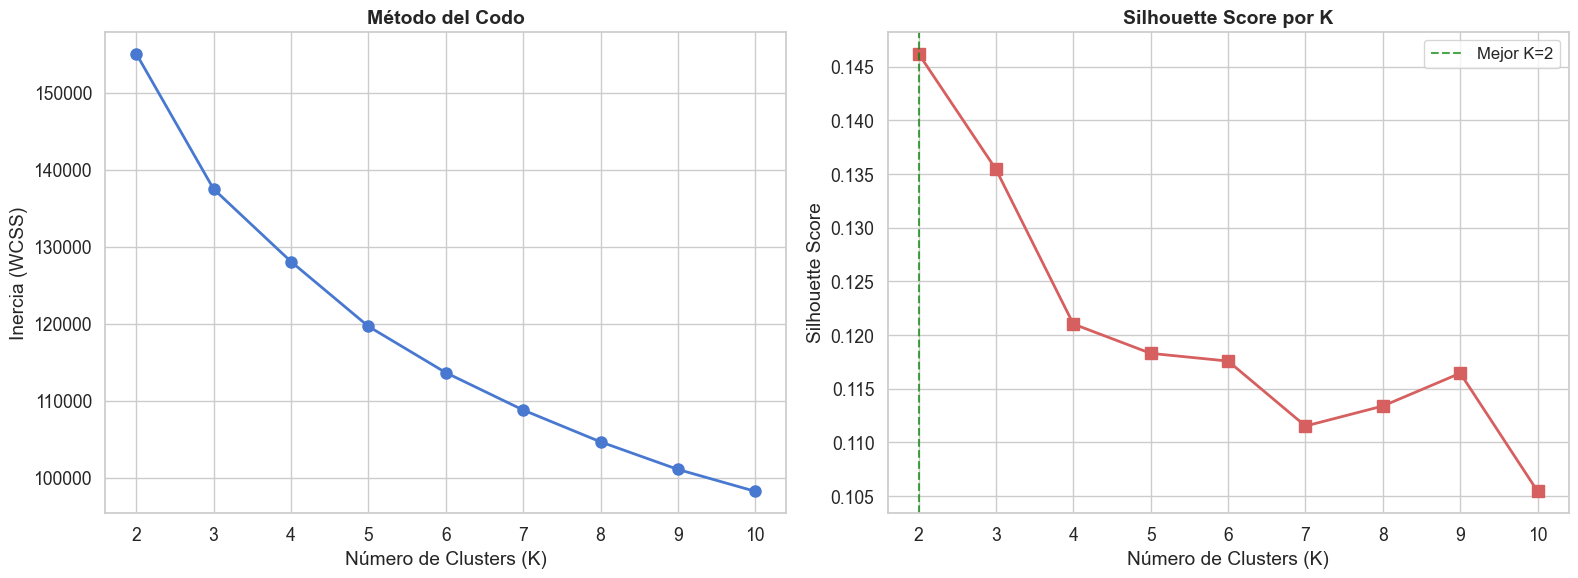

Mejor K según Silhouette Score: K=2 | Score=0.1462


In [8]:
# Gráficos del Codo y Silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Inercia (WCSS)')
ax1.set_title('Método del Codo')
ax1.set_xticks(list(K_range))

ax2.plot(list(K_range), silhouettes, 'rs-', linewidth=2, markersize=8)
ax2.set_xlabel('Número de Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score por K')
ax2.set_xticks(list(K_range))

best_k_idx = int(np.argmax(silhouettes))
best_k = list(K_range)[best_k_idx]
ax2.axvline(x=best_k, color='green', linestyle='--', alpha=0.7, label=f'Mejor K={best_k}')
ax2.legend(fontsize=12)

plt.tight_layout()
plt.savefig('../data/08_reporting/03_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mejor K según Silhouette Score: K={best_k} | Score={silhouettes[best_k_idx]:.4f}")

## 7. K-Means final — Entrenamiento con el K óptimo

In [9]:
K_FINAL = 4   # ajustar si el análisis del codo sugiere otro valor
print(f"K final seleccionado: {K_FINAL}")
print("(Basado en el análisis del codo y silhouette score)")

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20, max_iter=500)
df['CLUSTER'] = kmeans_final.fit_predict(X_pca)

print("\nDistribución de pacientes por cluster:")
for cluster_id in sorted(df['CLUSTER'].unique()):
    n   = (df['CLUSTER'] == cluster_id).sum()
    pct = n / len(df) * 100
    print(f"  Cluster {cluster_id}: {n:,} pacientes ({pct:.1f}%)")

sil_final = silhouette_score(X_pca, df['CLUSTER'])
print(f"\nSilhouette Score final: {sil_final:.4f}")

K final seleccionado: 4
(Basado en el análisis del codo y silhouette score)

Distribución de pacientes por cluster:
  Cluster 0: 3,144 pacientes (30.8%)
  Cluster 1: 2,468 pacientes (24.2%)
  Cluster 2: 2,171 pacientes (21.3%)
  Cluster 3: 2,431 pacientes (23.8%)

Silhouette Score final: 0.1210


## 8. Visualización de Clusters en espacio PCA 2D

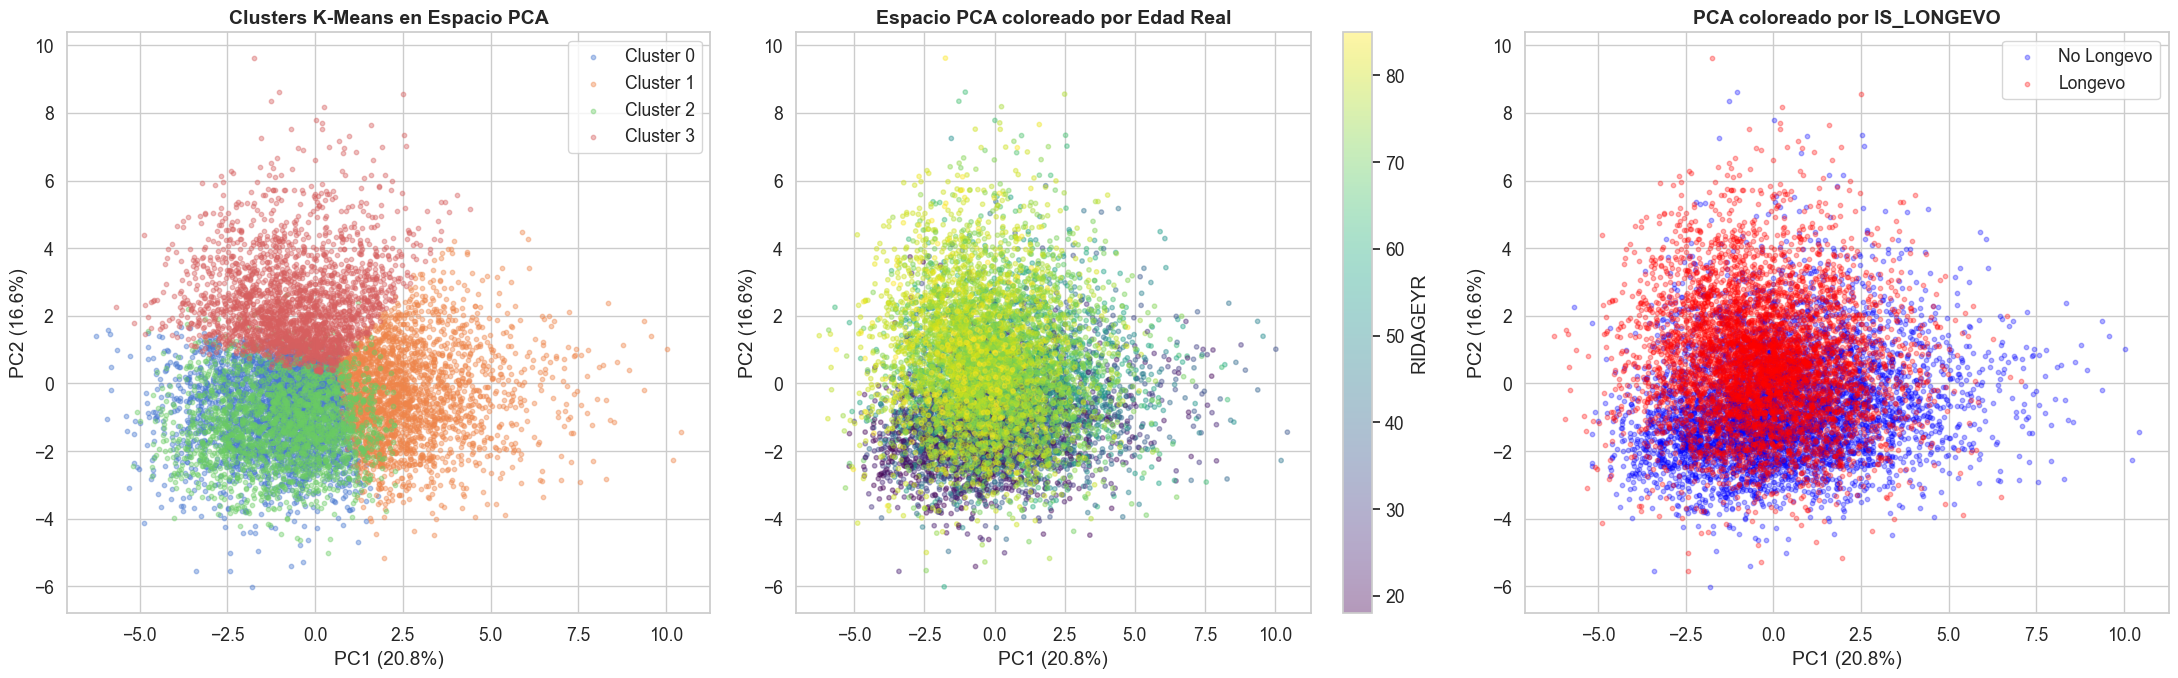

In [10]:
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X)

df_pca = pd.DataFrame(X_2d, columns=['PC1', 'PC2'])
df_pca['CLUSTER']    = df['CLUSTER'].values
df_pca['RIDAGEYR']   = df['RIDAGEYR'].values
df_pca['IS_LONGEVO'] = df['IS_LONGEVO'].values

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# 1. Clusters
for cid in sorted(df_pca['CLUSTER'].unique()):
    mask = df_pca['CLUSTER'] == cid
    axes[0].scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                    alpha=0.4, s=10, label=f'Cluster {cid}')
axes[0].set_title('Clusters K-Means en Espacio PCA')
axes[0].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].legend()

# 2. Coloreado por edad
sc = axes[1].scatter(df_pca['PC1'], df_pca['PC2'],
                     c=df_pca['RIDAGEYR'], cmap='viridis', alpha=0.4, s=10)
axes[1].set_title('Espacio PCA coloreado por Edad Real')
axes[1].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
plt.colorbar(sc, ax=axes[1], label='RIDAGEYR')

# 3. Coloreado por IS_LONGEVO
for longevo, color, label in [(0, 'blue', 'No Longevo'), (1, 'red', 'Longevo')]:
    mask = df_pca['IS_LONGEVO'] == longevo
    axes[2].scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                    alpha=0.3, s=10, c=color, label=label)
axes[2].set_title('PCA coloreado por IS_LONGEVO')
axes[2].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
axes[2].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
axes[2].legend()

plt.tight_layout()
plt.savefig('../data/08_reporting/03_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Boxplots por cluster

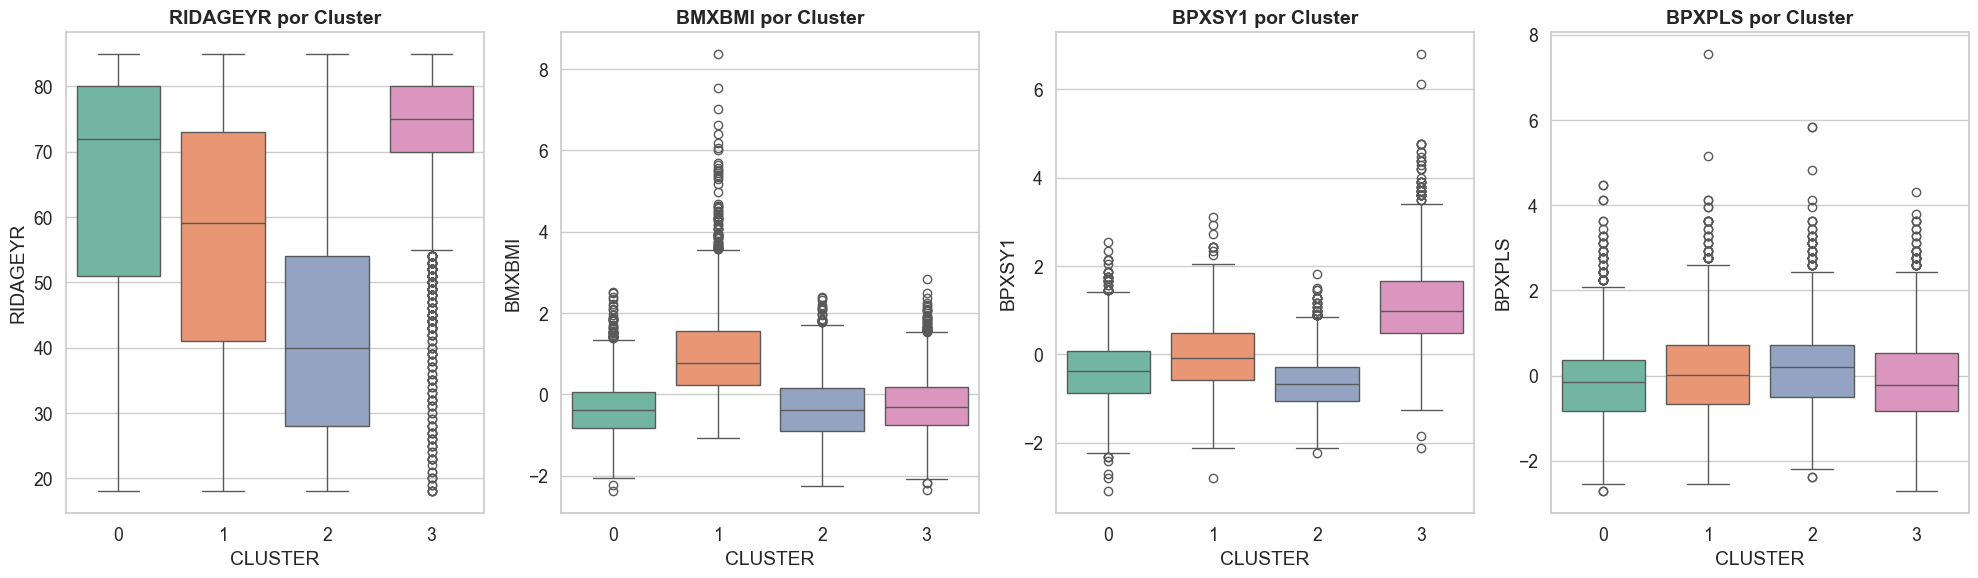

In [11]:
vars_box = [v for v in ['RIDAGEYR', 'BMXBMI', 'BPXSY1', 'BPXPLS'] if v in df.columns]
fig, axes = plt.subplots(1, len(vars_box), figsize=(5*len(vars_box), 6))

for i, var in enumerate(vars_box):
    sns.boxplot(data=df, x='CLUSTER', y=var, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{var} por Cluster')

plt.tight_layout()
plt.savefig('../data/08_reporting/03_cluster_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Interpretación de centroides — Fenotipos de salud

In [12]:
vars_interpretacion = [v for v in [
    'RIDAGEYR', 'BMXBMI', 'BMXWAIST', 'BMXWT', 'BMXHT',
    'BPXSY1', 'BPXDI1', 'BPXPLS', 'LBXTC', 'LBXGLU', 'DMDHHSIZ', 'INDFMPIR'
] if v in df.columns]

print("Perfil promedio de cada Cluster (valores escalados, excepto RIDAGEYR):")
perfil = df.groupby('CLUSTER')[vars_interpretacion].mean().round(2)
print(perfil.to_string())

Perfil promedio de cada Cluster (valores escalados, excepto RIDAGEYR):
         RIDAGEYR  BMXBMI  BMXWAIST  BMXWT  BMXHT  BPXSY1  BPXDI1  BPXPLS  LBXTC  LBXGLU  DMDHHSIZ  INDFMPIR
CLUSTER                                                                                                     
0           63.23   -0.36     -0.31  -0.35  -0.03   -0.41   -0.62   -0.14  -0.10   -0.14     -0.52      0.16
1           56.23    1.01      1.10   1.27   0.73   -0.02    0.34    0.09  -0.09    0.36     -0.05      0.12
2           42.72   -0.34     -0.53  -0.40  -0.20   -0.64    0.06    0.21  -0.06   -0.20      1.30     -0.22
3           71.56   -0.26     -0.24  -0.47  -0.53    1.12    0.40   -0.10   0.28   -0.01     -0.44     -0.14


In [13]:
# Proporción de longevos por cluster
print("Proporción de Longevos (IS_LONGEVO=1) por Cluster")
print("(Valida si los clusters capturan información de longevidad)")
print()

for cluster_id in sorted(df['CLUSTER'].unique()):
    subset    = df[df['CLUSTER'] == cluster_id]
    n_total   = len(subset)
    n_longevo = subset['IS_LONGEVO'].sum()
    pct       = n_longevo / n_total * 100 if n_total > 0 else 0
    edad_media = subset['RIDAGEYR'].mean()
    print(f"  Cluster {cluster_id}: {n_longevo:,}/{n_total:,} longevos "
          f"({pct:.1f}%) | Edad media: {edad_media:.1f} años")

Proporción de Longevos (IS_LONGEVO=1) por Cluster
(Valida si los clusters capturan información de longevidad)

  Cluster 0: 1,916/3,144 longevos (60.9%) | Edad media: 63.2 años
  Cluster 1: 945/2,468 longevos (38.3%) | Edad media: 56.2 años
  Cluster 2: 311/2,171 longevos (14.3%) | Edad media: 42.7 años
  Cluster 3: 1,830/2,431 longevos (75.3%) | Edad media: 71.6 años


## 11. Conclusiones

1. **PCA** logra capturar la mayor parte de la varianza en relativamente pocos
   componentes, confirmando que muchas variables clínicas están correlacionadas.
2. **K-Means** identifica fenotipos de salud diferenciados basándose únicamente
   en biomarcadores, sin conocer la edad ni la longevidad.
3. La proporción de longevos varía entre clusters, lo que sugiere que algunos
   perfiles metabólicos están más asociados a la longevidad que otros.
4. Estos clusters pueden usarse como segmentos de pacientes en la app de Edad Biológica.

---
**Siguiente Notebook → 04: Clasificación Supervisada (IS_LONGEVO)**

*Notebook generado como parte del pipeline EV3 NHANES 2013-2014*